# EGX360 — THE DEEP QUANT MODEL
### Enhancing Down-Trend Detection & Bias Control in the Egyptian Stock Exchange

## 1. Environment Setup & Initialization

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

import optuna
from sklearn.model_selection import cross_val_score
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

import tensorflow as tf

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"✅ GPU found by TF: {gpu_devices}")
else:
    print("⚠️ No GPU detected by TF. Running ML on CPU (Multicore Mode).")

/home/heiba/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-12 02:48:25.168223: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-12 02:48:25.174790: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-12 02:48:25.584981: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the a

⚠️ No GPU detected by TF. Running ML on CPU (Multicore Mode).


E0000 00:00:1778543309.164812   17846 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1778543309.302709   17846 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## 2. Data Loading & Merging
We begin by loading the preprocessed EGX30 daily data. Financial time series data is notoriously noisy. Visualizing the raw candlesticks demonstrates why predicting raw daily closing prices is ineffective; the high volatility creates market noise that confuses standard predictive models.

In [2]:
print("\nLoading Final Dataset (EGX + USD + Gold + Interest)...")
# load Data From Egx30
current_dir = os.getcwd()
file_path = os.path.join(current_dir, "data", "EGX30_Final_v9.csv")
df = pd.read_csv(file_path)

# Sort Data
df['timestamp'] = pd.to_datetime(df['timestamp']).dt.tz_localize(None).dt.normalize()
df.set_index('timestamp', inplace=True)
df.sort_index(inplace=True)

# Load Interest Data CIB and merging it 
ir_path = os.path.join(current_dir, "data", "cbe_interest_rate.csv")
if os.path.exists(ir_path):
    ir_df = pd.read_csv(ir_path)
    ir_df['Date'] = pd.to_datetime(ir_df['Date']).dt.normalize()
    ir_df.set_index('Date', inplace=True)
    
    df = df.join(ir_df, how='left')
    df['Interest_Rate'] = df['Interest_Rate'].ffill().bfill()
    df['IR_Change'] = df['Interest_Rate'].diff().fillna(0)
    print("Interest Rates Merged.")

df.dropna(inplace=True)
print(f"Base Data Shape: {df.shape}")


Loading Final Dataset (EGX + USD + Gold + Interest)...
Interest Rates Merged.
Base Data Shape: (6911, 16)


# 3. Macroeconomic Visualization

In [3]:
fig_macro = make_subplots(rows=3, cols=1, shared_xaxes=True, 
                          vertical_spacing=0.05,
                          subplot_titles=('EGX30 Close Price', 'USD/EGP Exchange Rate', 'Gold Price (EGP)'))

fig_macro.add_trace(go.Scatter(x=df.index, y=df['close'], mode='lines', name='EGX30', line=dict(color='black')), row=1, col=1)
fig_macro.add_trace(go.Scatter(x=df.index, y=df['usd_egp_rate'], mode='lines', name='USD/EGP', line=dict(color='green')), row=2, col=1)
fig_macro.add_trace(go.Scatter(x=df.index, y=df['gold_egp'], mode='lines', name='Gold (EGP)', line=dict(color='goldenrod')), row=3, col=1)

fig_macro.update_layout(height=800, title_text="Macroeconomic Trends in Egypt", template='plotly_white', hovermode='x unified')
fig_macro.show()

## 3. Advanced Feature Engineering (The Quant Indicators)
To make the data machine-readable, we engineer quantitative features. We translate raw price action into mathematical signals representing Trend, Momentum, and Volatility.



### 1. Macro-Economic Hedging (USD/EGP & Gold Translation)
In emerging markets like Egypt, local index prices are often heavily distorted by currency devaluation. To allow the model to see the "true" value of the market, we strip away inflation by pricing the index in USD. Conversely, we price Global Gold in EGP to quantify local safe-haven hedging behavior.

**Mathematical Formulas:**
$$ P^{usd}_t = \frac{P^{egp}_t}{Rate_t} \quad \text{(Pricing EGX in USD)} $$
$$ G^{egp}_t = G^{usd}_t \times Rate_t \quad \text{(Pricing Gold in Local Currency)} $$
$$ R^{usd}_t = \ln\left(\frac{P^{usd}_t + \epsilon}{P^{usd}_{t-1} + \epsilon}\right), \quad V^{usd}_t = R^{usd}_t - R^{usd}_{t-1} $$

In [4]:
# 1. USD Pricing & Velocity
if 'usd_egp_rate' in df.columns:
    df['close_usd'] = df['close'] / df['usd_egp_rate']
    df['log_ret_usd'] = np.log((df['close_usd'] + 1e-6) / (df['close_usd'].shift(1) + 1e-6))
    df['price_velocity_usd'] = df['log_ret_usd'].diff()
    df['log_ret_usd_lag1'] = df['log_ret_usd'].shift(1)

# 2. Local Gold Pricing & Velocity
if 'gold_usd' in df.columns and 'usd_egp_rate' in df.columns:
    df['gold_egp'] = df['gold_usd'] * df['usd_egp_rate']
    df['gold_log_ret'] = np.log((df['gold_egp'] + 1e-6) / (df['gold_egp'].shift(1) + 1e-6))
    df['gold_velocity'] = df['gold_log_ret'].diff()
    df['gold_ret_lag1'] = df['gold_log_ret'].shift(1)

### 2. Local Log Returns & Price Velocity
Absolute price changes are not statistically comparable over time. Logarithmic returns stabilize the variance. Price Velocity (the derivative of log returns) acts as a momentum acceleration metric and an early warning system for market crashes.

**Mathematical Formulas:**
$$ R_t = \ln\left(\frac{P_t + \epsilon}{P_{t-1} + \epsilon}\right) $$
$$ V_t = R_t - R_{t-1} $$

In [5]:
df['log_ret'] = np.log((df['close'] + 1e-6) / (df['close'].shift(1) + 1e-6))
df['price_velocity'] = df['log_ret'].diff()

### 3. Relative Volume (RVOL)
Volume alone lacks context. Relative Volume compares today's volume to the 50-day Simple Moving Average. An RVOL > 1 signifies abnormal liquidity, which often indicates institutional intervention.

**Mathematical Formula:**
$$ RVOL_t = \frac{Volume_t}{SMA_{50}(Volume) + \epsilon} $$

In [6]:
df['Volume_SMA_50'] = df['volume'].rolling(window=50).mean()
df['RVOL_50'] = (df['volume'] / (df['Volume_SMA_50'] + 1e-9)).clip(upper=5.0)

### 4. Cyclic Time Features
Tree-based models do not intuitively understand weekly cycles. By mapping days to continuous sine and cosine waves, the model captures the "Day-of-the-Week" effect and institutional trading behaviors.

**Mathematical Formulas:**
$$ X_{sin} = \sin\left(\frac{2\pi \cdot d}{7}\right), \quad X_{cos} = \cos\left(\frac{2\pi \cdot d}{7}\right) $$

In [7]:
df['day_sin'] = np.sin(2 * np.pi * df.index.dayofweek / 7)
df['day_cos'] = np.cos(2 * np.pi * df.index.dayofweek / 7)

### 5. Exponential Moving Averages (EMA) & Gap Analysis
The EMA assigns exponentially greater weight to recent prices. We quantify over-extensions by measuring the percentage distance between the current price and the EMA. We also extract fast/slow crossover signals.

**Mathematical Formulas:**
$$ EMA_t = \left( P_t \times \alpha \right) + \left( EMA_{t-1} \times (1 - \alpha) \right) $$
$$ Dist = \frac{P_t - EMA_t}{EMA_t} $$

In [8]:
for period in [9, 10, 20, 21,31, 50]:
    ema_col = f'EMA_{period}'
    df[ema_col] = df['close'].ewm(span=period).mean()
    df[f'dist_EMA_{period}'] = (df['close'] - df[ema_col]) / (df[ema_col] + 1e-9)

df['below_EMA9'] = (df['close'] < df['EMA_9']).astype(int)
df['EMA_Spread'] = (df['EMA_10'] - df['EMA_20']) / (df['EMA_20'] + 1e-9)
df['EMA_Cross_Signal'] = (df['EMA_10'] > df['EMA_20']).astype(int)

### 6. Momentum & Panic Detectors (RSI, MACD, BB, ATR)
Here, we quantify herd behavior (Panic & Greed):
*   **RSI & MACD:** Measures buying/selling exhaustion.
*   **ATR:** Measures daily volatility and risk as a percentage.
*   **Bollinger Bands Width:** Measures market "squeeze," mathematically preceding explosive volatility.
*   **Stochastic K:** Detects rapid price bounds.

**Key Mathematical Formulas:**
$$ RSI = 100 - \frac{100}{1 + RS} $$
$$ MACD = EMA_{12} - EMA_{26} $$
$$ BB_{width} = \frac{4 \times \sigma_{20}}{SMA_{20}} $$

In [9]:
delta = df['close'].diff()
gain = delta.where(delta > 0, 0).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
df['RSI'] = 100 - (100 / (1 + gain/(loss + 1e-9)))
df['RSI_diff'] = df['RSI'].diff()

macd = df['close'].ewm(span=12).mean() - df['close'].ewm(span=26).mean()
df['MACD_Hist'] = macd - macd.ewm(span=9).mean()

tr = pd.concat([df['high'] - df['low'], 
                np.abs(df['high'] - df['close'].shift()), 
                np.abs(df['low'] - df['close'].shift())], axis=1).max(axis=1)
df['ATR_pct'] = tr.rolling(14).mean() / (df['close'] + 1e-9)

low_14 = df['low'].rolling(14).min()
high_14 = df['high'].rolling(14).max()
df['Stoch_K'] = 100 * ((df['close'] - low_14) / (high_14 - low_14 + 1e-9))

ma20 = df['close'].rolling(20).mean()
std20 = df['close'].rolling(20).std()
df['BB_Width'] = (std20 * 4) / (ma20 + 1e-9)

### 7. Temporal Lags & Target Engineering
Predicting raw daily closing prices essentially models a Random Walk. By setting the target as the future direction of the baseline trend ($EMA_{10}$), we train the model to predict underlying mechanics, successfully filtering market noise.

**Mathematical Formula for Target:**
$$ Target = \begin{cases} 1 & \text{if } P_{t+1} > EMA_{10}(P_t) \\ 0 & \text{otherwise} \end{cases} $$

In [10]:
# Temporal Lags
df['log_ret_lag1'] = df['log_ret'].shift(1)
df['RSI_lag1'] = df['RSI'].shift(1)

# Target: Future Trend Direction
df['Target'] = (df['close'].shift(-1) > df['EMA_10']).astype(int)

### 1. Macro-Economic Shock Sensors (Leading Indicators)
Technical indicators like RSI and EMA are inherently lagging—they react to price changes after they happen. In the Egyptian market, macro-shocks (devaluation or interest rate hikes) move the market instantly. These "Flags" act as leading indicators, giving the model an immediate signal to override technical noise during crises.

**Logic:**
- **USD Shock:** Triggered if USD/EGP price velocity exceeds 2% in a single day.
- **Interest Rate Flags:** Binary sensors for Rate Hikes or Drops based on Central Bank of Egypt (CBE) data.

In [11]:
# Shock Sensors Implementation
if 'price_velocity_usd' in df.columns:
    df['USD_Shock'] = (df['price_velocity_usd'] > 0.02).astype(int)

if 'IR_Change' in df.columns:
    df['Rate_Hike_Flag'] = (df['IR_Change'] > 0).astype(int)
    df['Rate_Drop_Flag'] = (df['IR_Change'] < 0).astype(int)

### 2. Feature Fusion: Composite Momentum
Using both RSI and Stochastic Oscillator can lead to "Multicollinearity," where the model receives redundant information. We fuse them into a single **Composite Momentum** metric. This stabilizes the signal, reduces noise, and prevents the model from over-relying on overlapping indicators.

**Mathematical Formula:**
$$ Composite\_Momentum = \frac{RSI + Stochastic\_K}{2} $$

In [12]:
# Dimensionality Reduction (Momentum Fusion)
if 'RSI' in df.columns and 'Stoch_K' in df.columns:
    df['Composite_Momentum'] = (df['RSI'] + df['Stoch_K']) / 2
    df.drop(columns=['Stoch_K'], inplace=True, errors='ignore')

### 3. Data Sanitization (Final Cleanup)
After engineering features using rolling windows and lags, the first few rows of the dataset inevitably contain NaN values. To ensure the Machine Learning models (XGBoost/LightGBM) can train without errors, we perform a final drop of these incomplete records.

**Logic:**
- **dropna():** Removes rows with missing values to ensure matrix integrity for training.

In [13]:
# Final Sanitization
df.dropna(inplace=True)
print(f"Data cleaned! Total Features available for ML: {len(df.columns)}")


features_to_drop = ['Target', 'timestamp', 'Date', 'close', 'open', 'high', 'low', 'volume', 'close_usd', 'usd_egp_rate', 'gold_egp']
final_features = [col for col in df.columns if col not in features_to_drop]


Data cleaned! Total Features available for ML: 50


In [14]:
# ------------------------------------------------------------
# Noise Filtration Visualization
# ------------------------------------------------------------
sample_df = df.tail(250) # Viewing the last 250 days for clarity
fig_noise = go.Figure()

# Raw Noisy Price
fig_noise.add_trace(go.Scatter(
    x=sample_df.index, y=sample_df['close'],
    mode='lines', name='Noisy Raw Price',
    line=dict(color='lightgray', width=1)
))

# Smoothed Signal (Target Baseline)
fig_noise.add_trace(go.Scatter(
    x=sample_df.index, y=sample_df['EMA_10'],
    mode='lines', name='Smoothed Signal (EMA 10)',
    line=dict(color='blue', width=2)
))

fig_noise.update_layout(
    title='EGX360 Noise Analysis: Raw Price vs. Target Signal',
    yaxis_title='Price (EGP)',
    template='plotly_white',
    hovermode='x unified'
)
fig_noise.show()

In [15]:
# ------------------------------------------------------------
# Chart 1: Visualizing Raw Noise (Residuals)
# ------------------------------------------------------------
df['noise'] = df['close'] - df['EMA_10']

fig_noise = make_subplots(rows=2, cols=1, shared_xaxes=True, 
                          subplot_titles=('Raw Price vs. Smoothed Trend', 'Extracted Market Noise (Residuals)'))

# Subplot 1: Price vs EMA
fig_noise.add_trace(go.Scatter(x=df.index[-300:], y=df['close'][-300:], name='Raw Price', line=dict(color='lightgray')), row=1, col=1)
fig_noise.add_trace(go.Scatter(x=df.index[-300:], y=df['EMA_10'][-300:], name='Signal (EMA 10)', line=dict(color='blue')), row=1, col=1)

# Subplot 2: The Noise itself
fig_noise.add_trace(go.Scatter(x=df.index[-300:], y=df['noise'][-300:], name='Noise', fill='tozeroy', line=dict(color='red')), row=2, col=1)

fig_noise.update_layout(height=700, title_text="EGX360: Noise Extraction Analysis", template='plotly_white')
fig_noise.show()

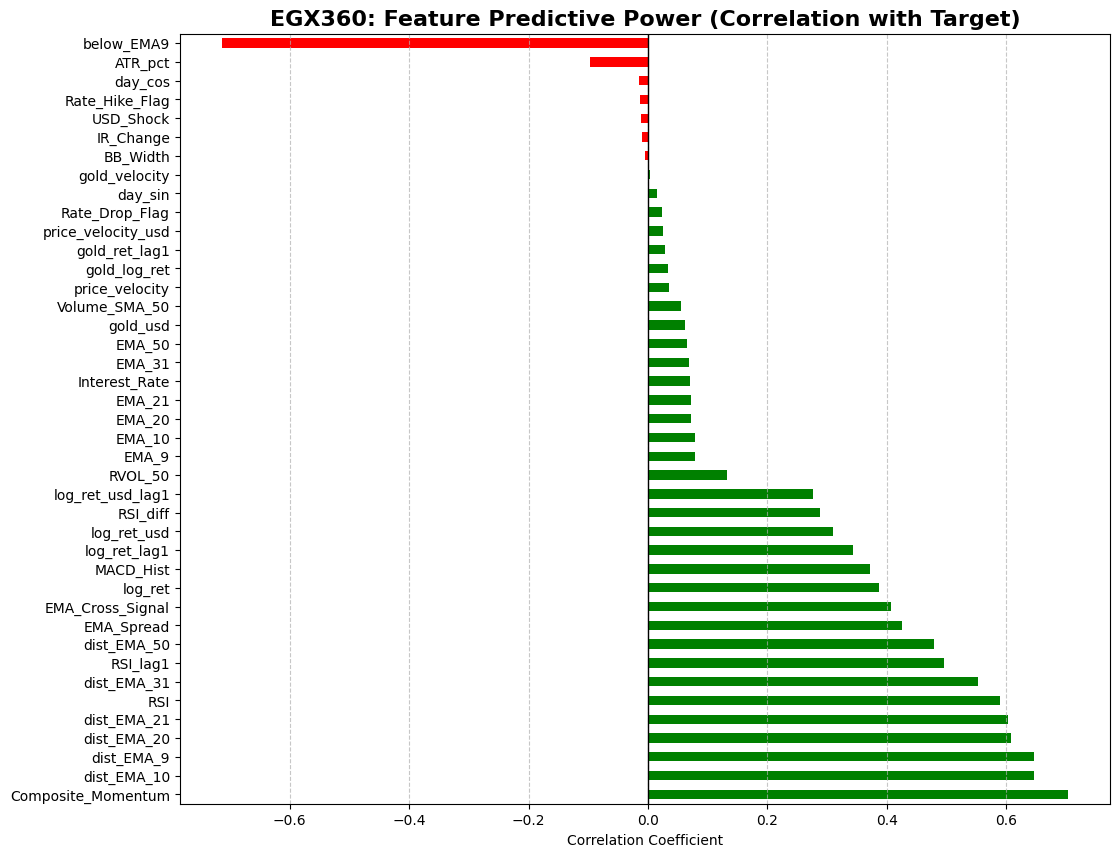

In [16]:
# ------------------------------------------------------------
# Chart 3: Correlation Ranking with Target
# ------------------------------------------------------------
target_corr = df[final_features].corrwith(df['Target']).sort_values(ascending=False)

plt.figure(figsize=(12, 10))
colors = ['green' if x > 0 else 'red' for x in target_corr]
target_corr.plot(kind='barh', color=colors)

plt.title("EGX360: Feature Predictive Power (Correlation with Target)", fontsize=16, fontweight='bold')
plt.xlabel("Correlation Coefficient")
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 4 MACHINE LEARNING

In financial time-series forecasting, we must avoid "Look-ahead Bias." We cannot use random splitting (Shuffle=True) because the model would learn from future data points to predict the past. We implement a Chronological Split, using the first 80% of historical data for training and the final 20% for out-of-sample testing.

Additionally, we drop raw price features and metadata (timestamps) to ensure the model learns from the engineered alpha signals rather than memorizing specific price levels.

In [17]:
# Protecting essential columns from training

X = df[final_features].values
y = df['Target'].values

# Chronological Split (No Shuffling)
split = int(len(X) * 0.80)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Hyperparameter Optimization with Optuna

Instead of manual tuning or inefficient Grid Searches, we utilize Optuna—a Bayesian optimization framework. It intelligently searches the hyperparameter space for XGBoost and LightGBM to maximize the cross-validation accuracy.

We focus on parameters that control model complexity (max_depth) and learning speed (learning_rate) to prevent overfitting on market noise.

In [19]:
# --- XGBoost Tuning ---
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'random_state': 42,
        'tree_method': 'hist',
        'n_jobs': -1 
    }
    model = xgb.XGBClassifier(**params)
    return cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()

print("Starting Optuna Tuning for XGBoost...")
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=1) 
best_xgb_params = study_xgb.best_params

# --- LightGBM Tuning ---
def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'random_state': 42,
        'verbose': -1,
        'n_jobs': -1
    }
    model = lgb.LGBMClassifier(**params)
    return cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()

print("Starting Optuna Tuning for LightGBM...")
study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=1)
best_lgb_params = study_lgb.best_params

Starting Optuna Tuning for XGBoost...
Starting Optuna Tuning for LightGBM...


## Stacking Ensemble Architecture

To achieve maximum robustness, we implement a Stacking Classifier. This architecture uses two diverse base models (XGBoost and LightGBM) to generate initial predictions. These predictions are then fed into a Meta-Learner (Logistic Regression).

The meta-learner learns which base model is more reliable under different market conditions, effectively creating a "Committee of Experts" that outperforms any single model.

In [20]:
# Initialize base models with optimized parameters
best_xgb = xgb.XGBClassifier(**best_xgb_params, random_state=42, tree_method='hist', n_jobs=-1)
best_lgb = lgb.LGBMClassifier(**best_lgb_params, random_state=42, verbose=-1, n_jobs=-1)

# Define the ensemble structure
base_models = [('xgb', best_xgb), ('lgbm', best_lgb)]
final_logic = LogisticRegression(C=1.0) 

# Build and fit the Stacking Classifier
stack_model = StackingClassifier(estimators=base_models, final_estimator=final_logic, cv=5)
stack_model.fit(X_train_scaled, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('xgb', ...), ('lgbm', ...)]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegression()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by usi

# 5. Final Evaluation & Strategy Visualization


In [21]:
# ------------------------------------------------------------
# 7. Final Evaluation & Strategy Visualization
# ------------------------------------------------------------
y_pred = stack_model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred) * 100

print(f"\nDEEP QUANT ACCURACY: {acc:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Down Trend (0)', 'Up Trend (1)']))

# Strategy Visualization
print("\nGenerating Strategy Visualization...")
test_dates = pd.Series(df.index[split:]).reset_index(drop=True)
test_close = df['close'].iloc[split:].reset_index(drop=True)
test_ema10 = df['EMA_10'].iloc[split:].reset_index(drop=True)

results_df = pd.DataFrame({'timestamp': test_dates, 'close': test_close, 'EMA_10': test_ema10, 'Predicted_Trend': y_pred})
viz_df = results_df.tail(150)

fig_test = go.Figure()
fig_test.add_trace(go.Scatter(x=viz_df['timestamp'], y=viz_df['close'], mode='lines', name='Close Price', line=dict(color='rgba(128,128,128,0.5)', width=1.5)))
fig_test.add_trace(go.Scatter(x=viz_df['timestamp'], y=viz_df['EMA_10'], mode='lines', name='EMA 10 (Target)', line=dict(color='blue', width=2)))

buy_signals = viz_df[viz_df['Predicted_Trend'] == 1]
sell_signals = viz_df[viz_df['Predicted_Trend'] == 0]
fig_test.add_trace(go.Scatter(x=buy_signals['timestamp'], y=buy_signals['EMA_10'], mode='markers', name='Signal: UP', marker=dict(color='green', symbol='triangle-up', size=12)))
fig_test.add_trace(go.Scatter(x=sell_signals['timestamp'], y=sell_signals['EMA_10'], mode='markers', name='Signal: DOWN', marker=dict(color='red', symbol='triangle-down', size=12)))
fig_test.update_layout(title='EGX360 Live Signals: Predictions vs Actual', yaxis_title='Price (EGP)', template='plotly_white', hovermode='x unified')
fig_test.show()




DEEP QUANT ACCURACY: 84.49%

Classification Report:
                precision    recall  f1-score   support

Down Trend (0)       0.79      0.79      0.79       511
  Up Trend (1)       0.88      0.88      0.88       862

      accuracy                           0.84      1373
     macro avg       0.83      0.83      0.83      1373
  weighted avg       0.84      0.84      0.84      1373


Generating Strategy Visualization...


In [ ]:
# ------------------------------------------------------------
# 7. Final Evaluation, Backtesting & Strategy Visualization
# ------------------------------------------------------------
y_pred = stack_model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred) * 100

print(f"\nDEEP QUANT ACCURACY: {acc:.2f}%")

test_dates = pd.Series(df.index[split:]).reset_index(drop=True)
test_close = df['close'].iloc[split:].reset_index(drop=True)
test_ema10 = df['EMA_10'].iloc[split:].reset_index(drop=True)

results_df = pd.DataFrame({'timestamp': test_dates, 'close': test_close, 'EMA_10': test_ema10, 'Predicted_Trend': y_pred})

# ============================================================
# NEW: Backtesting Logic
# ============================================================
initial_capital = 10000.0

# Calculate actual daily percentage returns of the closing price
results_df['daily_return'] = results_df['close'].pct_change()

# CRITICAL: Shift the signal by 1 day to prevent look-ahead bias.
results_df['signal'] = results_df['Predicted_Trend'].shift(1)

# Strategy Return Calculation
results_df['strategy_return'] = results_df['daily_return'] * results_df['signal']

# Drop the first row which will have NaNs due to shifting/pct_change
bt_df = results_df.dropna().copy()

# Cumulative Returns
bt_df['cumulative_market'] = (1 + bt_df['daily_return']).cumprod()
bt_df['cumulative_strategy'] = (1 + bt_df['strategy_return']).cumprod()

# Monetary Value Tracking
bt_df['portfolio_value'] = initial_capital * bt_df['cumulative_strategy']
bt_df['bh_value'] = initial_capital * bt_df['cumulative_market']

final_portfolio = bt_df['portfolio_value'].iloc[-1]
final_bh = bt_df['bh_value'].iloc[-1]

strategy_profit_pct = ((final_portfolio - initial_capital) / initial_capital) * 100
market_profit_pct = ((final_bh - initial_capital) / initial_capital) * 100
outperformance = strategy_profit_pct - market_profit_pct

print(f"\n Initial Capital: {initial_capital:,.2f} EGP")
print("-" * 40)
print(f"1) Buy & Hold Strategy (Market): {final_bh:,.2f} EGP ({market_profit_pct:.2f}%)")
print(f"2) EGX360 Strategy (Model):      {final_portfolio:,.2f} EGP ({strategy_profit_pct:.2f}%)")
print("-" * 40)
print(f" The EGX360 Model outperformed the market by: {outperformance:.2f}%\n")

# Backtest Chart
fig_bt = go.Figure()
fig_bt.add_trace(go.Scatter(x=bt_df['timestamp'], y=bt_df['portfolio_value'], mode='lines', name='EGX360 Strategy', line=dict(color='green', width=2.5)))
fig_bt.add_trace(go.Scatter(x=bt_df['timestamp'], y=bt_df['bh_value'], mode='lines', name='Buy & Hold Baseline', line=dict(color='gray', width=1.5, dash='dash')))
fig_bt.update_layout(title='EGX360 Financial Backtest: Portfolio Growth', yaxis_title='Portfolio Value (EGP)', template='plotly_white', hovermode='x unified')
fig_bt.show()

# ============================================================
# 8. EGX360 API JSON Generator (Updated with Backtest Data)
# ============================================================
latest_date = df.index[-1]
last_day_data = df.iloc[-1]

api_response = {
    "date": str(latest_date.date()),
    "raw_market_data": {},
    "all_computed_features": {},
    "smart_analysis": {},
    "consensus": {},
    "ml_prediction": {},
    "backtest_results": {}  # <-- تم إضافة القسم هنا
}


api_response["backtest_results"] = {
    "initial_capital": float(initial_capital),
    "final_strategy_value": round(float(final_portfolio), 2),
    "final_market_value": round(float(final_bh), 2),
    "strategy_profit_pct": round(float(strategy_profit_pct), 2),
    "market_profit_pct": round(float(market_profit_pct), 2),
    "outperformance_pct": round(float(outperformance), 2)
}
# ============================================================
# 8. EGX360 FULL API JSON Generator (Features + Backtest)
# ============================================================
print("\n" + "="*50)
print("📦 PACKAGING ALL DATA & BACKTEST FOR SERVER (FULL JSON)")
print("="*50)

latest_date = df.index[-1]
last_day_data = df.iloc[-1]

api_response = {
    "date": str(latest_date.date()),
    "raw_market_data": {},
    "all_computed_features": {},
    "smart_analysis": {},
    "consensus": {},
    "ml_prediction": {},
    "backtest_results": {}
}

# 1. Raw Market Data
raw_cols = ['open', 'high', 'low', 'close', 'volume', 'usd_egp_rate', 'gold_egp']
for col in raw_cols:
    if col in df.columns:
        api_response["raw_market_data"][col] = float(last_day_data[col])

# 2. Dynamic Feature Extraction (35+ Indicators)
for col in df.columns:
    if col not in raw_cols and col not in ['Target', 'Date', 'timestamp']:
        val = last_day_data[col]
        if pd.isna(val):
            api_response["all_computed_features"][col] = None
        elif isinstance(val, (np.integer, int)):
            api_response["all_computed_features"][col] = int(val)
        elif isinstance(val, (np.floating, float)):
            api_response["all_computed_features"][col] = round(float(val), 6)
        else:
            api_response["all_computed_features"][col] = str(val)

# 3. Smart Analysis with Granular Correlation Mapping
votes = {'UP': 0, 'DOWN': 0, 'NEUTRAL': 0}

if 'Composite_Momentum' in df.columns:
    val = float(last_day_data['Composite_Momentum'])
    if val >= 80: 
        state, color = "Very High (Overbought)", "CRITICAL_RED"
        votes['DOWN'] += 1
    elif val >= 70: 
        state, color = "High", "RED"
        votes['DOWN'] += 1
    elif val <= 20: 
        state, color = "Very Decrease (Oversold)", "CRITICAL_GREEN"
        votes['UP'] += 1
    elif val <= 30: 
        state, color = "Decrease", "GREEN"
        votes['UP'] += 1
    else: 
        state, color = "Normal (Stable)", "GREY"
        votes['NEUTRAL'] += 1
    api_response["smart_analysis"]["momentum"] = {"value": round(val, 2), "status": state, "ui_color": color}

if 'MACD_Hist' in df.columns:
    val = float(last_day_data['MACD_Hist'])
    if val > 0:
        state = "High Bullish Momentum" if val > (df['MACD_Hist'].std()) else "Normal Positive"
        votes['UP'] += 1
    else:
        state = "Very Decrease (Bearish Pressure)" if val < -(df['MACD_Hist'].std()) else "Decrease"
        votes['DOWN'] += 1
    api_response["smart_analysis"]["macd"] = {"status": state}

if 'ATR_pct' in df.columns:
    val = float(last_day_data['ATR_pct']) * 100
    if val > 2.5: state = "Very High Volatility (High Risk)"
    elif val > 1.5: state = "High Volatility"
    else: state = "Normal / Low Risk"
    api_response["smart_analysis"]["volatility"] = {"status": state}

# 4. Consensus & Trend Result
total_votes = sum(votes.values())
if total_votes > 0:
    up_pct = round((votes['UP'] / total_votes) * 100, 1)
    down_pct = round((votes['DOWN'] / total_votes) * 100, 1)
    
    if up_pct > 60: trend = "STRONG BULLISH"
    elif up_pct > 50: trend = "BULLISH"
    elif down_pct > 60: trend = "STRONG BEARISH"
    elif down_pct > 50: trend = "BEARISH"
    else: trend = "NEUTRAL / SIDEWAYS"
    
    api_response["consensus"] = {"up_percentage": up_pct, "down_percentage": down_pct, "overall_trend": trend}

# 5. Machine Learning Core Output
latest_features = X_test_scaled[-1].reshape(1, -1)
ml_pred = int(stack_model.predict(latest_features)[0])
ml_prob = float(stack_model.predict_proba(latest_features)[0][1]) * 100

api_response["ml_prediction"] = {
    "signal": "UP" if ml_pred == 1 else "DOWN",
    "confidence_percentage": round(ml_prob if ml_pred == 1 else 100 - ml_prob, 2),
    "model_version": "EGX360_Deep_Quant_v8.4"
}

# 6. Backtest Results Addition
api_response["backtest_results"] = {
    "initial_capital": float(initial_capital),
    "final_strategy_value": round(float(final_portfolio), 2),
    "final_market_value": round(float(final_bh), 2),
    "strategy_profit_pct": round(float(strategy_profit_pct), 2),
    "market_profit_pct": round(float(market_profit_pct), 2),
    "outperformance_pct": round(float(outperformance), 2)
}

# Final Export
output_filename = "egx360_daily_signal.json"
with open(output_filename, 'w', encoding='utf-8') as f:
    json.dump(api_response, f, ensure_ascii=False, indent=4)

print(f"✅ Success! Data perfectly packaged into '{output_filename}'")
# Final Export
output_filename = "egx360_daily_signal.json"
with open(output_filename, 'w', encoding='utf-8') as f:
    json.dump(api_response, f, ensure_ascii=False, indent=4)

print(f"✅ Success! Data and Backtest stats perfectly packaged into '{output_filename}'")


DEEP QUANT ACCURACY: 84.49%

 Initial Capital: 10,000.00 EGP
----------------------------------------
1) Buy & Hold Strategy (Market): 46,838.72 EGP (368.39%)
2) EGX360 Strategy (Model):      60,036.28 EGP (500.36%)
----------------------------------------
 The EGX360 Model outperformed the market by: 131.98%



✅ Success! Data and Backtest stats perfectly packaged into 'egx360_daily_signal.json'


In [27]:
# ============================================================
# 8. EGX360 FULL API JSON Generator (Features + Backtest)
# ============================================================
print("\n" + "="*50)
print("📦 PACKAGING ALL DATA & BACKTEST FOR SERVER (FULL JSON)")
print("="*50)

latest_date = df.index[-1]
last_day_data = df.iloc[-1]

api_response = {
    "date": str(latest_date.date()),
    "raw_market_data": {},
    "all_computed_features": {},
    "smart_analysis": {},
    "consensus": {},
    "ml_prediction": {},
    "backtest_results": {}
}

# 1. Raw Market Data
raw_cols = ['open', 'high', 'low', 'close', 'volume', 'usd_egp_rate', 'gold_egp']
for col in raw_cols:
    if col in df.columns:
        api_response["raw_market_data"][col] = float(last_day_data[col])

# 2. Dynamic Feature Extraction (35+ Indicators)
for col in df.columns:
    if col not in raw_cols and col not in ['Target', 'Date', 'timestamp']:
        val = last_day_data[col]
        if pd.isna(val):
            api_response["all_computed_features"][col] = None
        elif isinstance(val, (np.integer, int)):
            api_response["all_computed_features"][col] = int(val)
        elif isinstance(val, (np.floating, float)):
            api_response["all_computed_features"][col] = round(float(val), 6)
        else:
            api_response["all_computed_features"][col] = str(val)

# 3. Smart Analysis with Granular Correlation Mapping
votes = {'UP': 0, 'DOWN': 0, 'NEUTRAL': 0}

if 'Composite_Momentum' in df.columns:
    val = float(last_day_data['Composite_Momentum'])
    if val >= 80: 
        state, color = "Very High (Overbought)", "CRITICAL_RED"
        votes['DOWN'] += 1
    elif val >= 70: 
        state, color = "High", "RED"
        votes['DOWN'] += 1
    elif val <= 20: 
        state, color = "Very Decrease (Oversold)", "CRITICAL_GREEN"
        votes['UP'] += 1
    elif val <= 30: 
        state, color = "Decrease", "GREEN"
        votes['UP'] += 1
    else: 
        state, color = "Normal (Stable)", "GREY"
        votes['NEUTRAL'] += 1
    api_response["smart_analysis"]["momentum"] = {"value": round(val, 2), "status": state, "ui_color": color}

if 'MACD_Hist' in df.columns:
    val = float(last_day_data['MACD_Hist'])
    if val > 0:
        state = "High Bullish Momentum" if val > (df['MACD_Hist'].std()) else "Normal Positive"
        votes['UP'] += 1
    else:
        state = "Very Decrease (Bearish Pressure)" if val < -(df['MACD_Hist'].std()) else "Decrease"
        votes['DOWN'] += 1
    api_response["smart_analysis"]["macd"] = {"status": state}

if 'ATR_pct' in df.columns:
    val = float(last_day_data['ATR_pct']) * 100
    if val > 2.5: state = "Very High Volatility (High Risk)"
    elif val > 1.5: state = "High Volatility"
    else: state = "Normal / Low Risk"
    api_response["smart_analysis"]["volatility"] = {"status": state}

# 4. Consensus & Trend Result
total_votes = sum(votes.values())
if total_votes > 0:
    up_pct = round((votes['UP'] / total_votes) * 100, 1)
    down_pct = round((votes['DOWN'] / total_votes) * 100, 1)
    
    if up_pct > 60: trend = "STRONG BULLISH"
    elif up_pct > 50: trend = "BULLISH"
    elif down_pct > 60: trend = "STRONG BEARISH"
    elif down_pct > 50: trend = "BEARISH"
    else: trend = "NEUTRAL / SIDEWAYS"
    
    api_response["consensus"] = {"up_percentage": up_pct, "down_percentage": down_pct, "overall_trend": trend}

# 5. Machine Learning Core Output
latest_features = X_test_scaled[-1].reshape(1, -1)
ml_pred = int(stack_model.predict(latest_features)[0])
ml_prob = float(stack_model.predict_proba(latest_features)[0][1]) * 100

api_response["ml_prediction"] = {
    "signal": "UP" if ml_pred == 1 else "DOWN",
    "confidence_percentage": round(ml_prob if ml_pred == 1 else 100 - ml_prob, 2),
    "model_version": "EGX360_Deep_Quant_v8.4"
}

# 6. Backtest Results Addition
api_response["backtest_results"] = {
    "initial_capital": float(initial_capital),
    "final_strategy_value": round(float(final_portfolio), 2),
    "final_market_value": round(float(final_bh), 2),
    "strategy_profit_pct": round(float(strategy_profit_pct), 2),
    "market_profit_pct": round(float(market_profit_pct), 2),
    "outperformance_pct": round(float(outperformance), 2)
}

# Final Export
output_filename = "egx360_daily_signal.json"
with open(output_filename, 'w', encoding='utf-8') as f:
    json.dump(api_response, f, ensure_ascii=False, indent=4)

print(f"✅ Success! Data perfectly packaged into '{output_filename}'")


📦 PACKAGING ALL DATA & BACKTEST FOR SERVER (FULL JSON)
✅ Success! Data perfectly packaged into 'egx360_daily_signal.json'


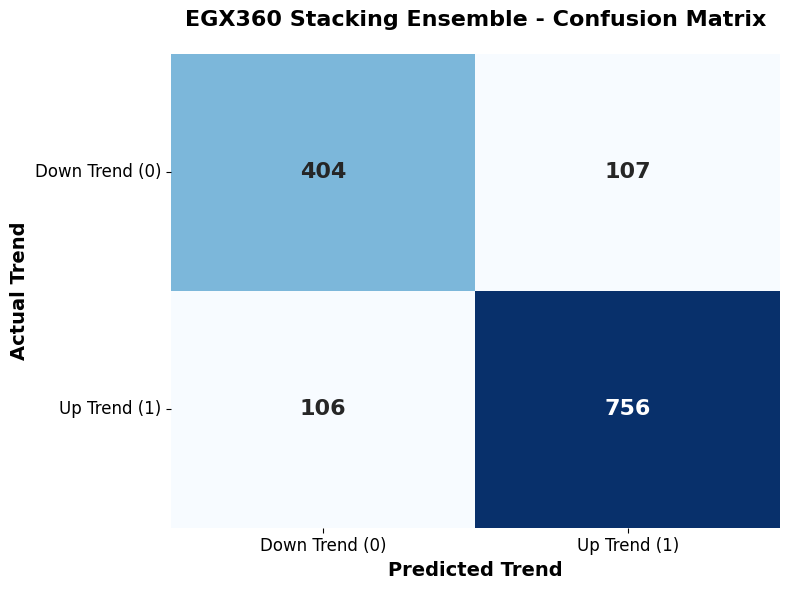

In [23]:
# 1. Generate the matrix numbers
cm = confusion_matrix(y_test, y_pred)

# 2. Plotting the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Down Trend (0)', 'Up Trend (1)'],
            yticklabels=['Down Trend (0)', 'Up Trend (1)'],
            annot_kws={"size": 16, "weight": "bold"}) # Make numbers large and readable

# 3. Styling for thesis publication
plt.title('EGX360 Stacking Ensemble - Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Trend', fontsize=14, fontweight='bold')
plt.ylabel('Actual Trend', fontsize=14, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)

plt.tight_layout()
plt.show()

In [28]:
import joblib

joblib.dump(stack_model, 'egx360_stack_model.pkl')

joblib.dump(scaler, 'egx360_scaler.pkl')

['egx360_scaler.pkl']

In [29]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 6862 entries, 1998-03-19 to 2026-04-30
Data columns (total 51 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   open                6862 non-null   float64
 1   high                6862 non-null   float64
 2   low                 6862 non-null   float64
 3   close               6862 non-null   float64
 4   volume              6862 non-null   int64  
 5   usd_egp_rate        6862 non-null   float64
 6   close_usd           6862 non-null   float64
 7   log_ret_usd         6862 non-null   float64
 8   price_velocity_usd  6862 non-null   float64
 9   gold_usd            6862 non-null   float64
 10  gold_egp            6862 non-null   float64
 11  gold_log_ret        6862 non-null   float64
 12  gold_velocity       6862 non-null   float64
 13  gold_ret_lag1       6862 non-null   float64
 14  Interest_Rate       6862 non-null   float64
 15  IR_Change           6862 non-null   float64
 16 